<a href="https://colab.research.google.com/github/emily-coding-kim/426-final/blob/main/BaselineCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline CNN — Album Cover Genre Classification

This notebook builds a **Baseline CNN** to classify album covers into music genres.
It serves as a performance reference point to compare against more advanced models (e.g. ResNet).

### Pipeline Overview
1. **Environment Setup** — imports, seeds, device selection
2. **Data Loading** — download dataset from Kaggle, apply transforms
3. **Genre Selection** — narrow the dataset to a subset of genres
4. **Data Cleaning** — remove duplicate album covers appearing in multiple genres
5. **Label Remapping** — reassign class indices to a clean 0-based range
6. **Class Distribution** — verify balance across selected genres

---
## 1. Environment Setup
Install and import all required libraries, fix random seeds for reproducibility,
and select the best available compute device.

In [ ]:
# Uncomment to install a specific version of kagglehub if needed
# !pip install kagglehub==1.0.0

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import time
import copy
import warnings
from collections import Counter, defaultdict
from itertools import combinations

warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import seaborn as sns
import matplotlib.pyplot as plt

# ── Machine learning utilities ────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# ── Kaggle dataset access ─────────────────────────────────────────────────────
import kagglehub

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

# ── PyTorch data utilities ────────────────────────────────────────────────────
from torch.utils.data import DataLoader, Subset, random_split

# ── PyTorch vision utilities ──────────────────────────────────────────────────
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

# ── Model summary ─────────────────────────────────────────────────────────────
from torchsummary import summary

In [ ]:
# ── Reproducibility ───────────────────────────────────────────────────────────
# Fix random seeds so results are consistent across runs
torch.manual_seed(42)
np.random.seed(42)

# ── Device selection ──────────────────────────────────────────────────────────
# Use GPU (CUDA) if available, then Apple Silicon (MPS), otherwise fall back to CPU.
# In Google Colab: Runtime → Change runtime type → T4 GPU to enable CUDA.
if torch.cuda.is_available():
    device = torch.device("cuda")       # NVIDIA GPU (recommended for Colab)
elif torch.backends.mps.is_available():
    device = torch.device("mps")        # Apple Silicon GPU
else:
    device = torch.device("cpu")        # fallback — training will be slow

print(f"Using device: {device}")

Using device: cuda


---
## 2. Data Loading
Download the album cover dataset from Kaggle and apply image transforms.

**Why these transforms?**
- `Resize(224, 224)` — CNN input layers require a fixed image size; 224×224 is a standard choice
- `ToTensor()` — converts PIL images to PyTorch tensors and rescales pixel values from [0, 255] → [0.0, 1.0]

> Note: ImageNet normalisation is intentionally **omitted** here. It is only meaningful
> when using pretrained ImageNet weights (e.g. ResNet). This is a from-scratch baseline.

In [ ]:
# Download the dataset — kagglehub caches it locally after the first download
path = kagglehub.dataset_download("michaeljkerr/20k-album-covers-within-20-genres")
print("Path to dataset files:", path)

100%|██████████| 226M/226M [00:01<00:00, 219MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/michaeljkerr/20k-album-covers-within-20-genres/versions/1


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE = 32   # number of images processed per training step

# ── Data root ─────────────────────────────────────────────────────────────────
# The dataset is organised as: GAID/<genre>/<image>.jpg
DATA_ROOT = os.path.join(path, 'GAID')

# ── Load full dataset ─────────────────────────────────────────────────────────
# ImageFolder automatically infers class labels from subfolder names
dataset = ImageFolder(root=DATA_ROOT, transform=None)

# ── Dataset summary ───────────────────────────────────────────────────────────
ALL_GENRES = dataset.classes
image, label = dataset[0]

print("Classes/genres in the dataset:", ALL_GENRES)
print("Total number of images:", len(dataset))
# print("Image tensor shape (channels, height, width):", image.shape)

Classes/genres in the dataset: ['Blues', 'Classical', 'Country', 'DeathMetal', 'DoomMetal', 'DrumNBass', 'Electronic', 'Folk', 'Grime', 'HeavyMetal', 'HipHop', 'Jazz', 'LoFi', 'Pop', 'PsychedelicRock', 'Punk', 'Reggae', 'Rock', 'Soul', 'Techno']
Total number of images: 20000


---
## 3. Genre Selection
The full dataset contains 20 genres. For the baseline we work with a manageable
5-genre subset — edit `SELECTED_GENRES` to change which genres are included.

In [ ]:
# ── Choose genres ─────────────────────────────────────────────────────────────
# Modify this list to include any genres from ALL_GENRES above
SELECTED_GENRES = ['Classical', 'DoomMetal', 'DeathMetal', 'Reggae', 'Punk']

# ── Filter dataset to selected genres ────────────────────────────────────────
# Retrieve the integer index assigned to each selected genre by ImageFolder
class_to_idx = dataset.class_to_idx
selected_indices = [class_to_idx[g] for g in SELECTED_GENRES]

# Keep only samples whose label belongs to a selected genre
filtered_samples = [
    (img_path, label)
    for img_path, label in dataset.samples
    if label in selected_indices
]

# Update the dataset in-place (imgs mirrors samples for ImageFolder compatibility)
dataset.samples = filtered_samples
dataset.imgs    = filtered_samples

print(f"Genres selected: {SELECTED_GENRES}")
print(f"Dataset size after genre filtering: {len(dataset)} images")

Genres selected: ['Classical', 'DoomMetal', 'DeathMetal', 'Reggae', 'Punk']
Dataset size after genre filtering: 5000 images


---
## 4. Data Cleaning — Remove Multi-Genre Duplicates
Some album covers appear in more than one genre folder (the same image file is
duplicated under different genre subdirectories). Including these would leak
information across classes, so we identify and remove them.

In [ ]:
# ── Identify duplicate filenames across genres ────────────────────────────────
# Build a map: filename → list of genres it appears in
file_to_genres = defaultdict(list)
for img_path, class_idx in dataset.samples:
    filename = os.path.basename(img_path)
    genre    = dataset.classes[class_idx]
    file_to_genres[filename].append(genre)

# A file is a duplicate if it appears under more than one distinct genre
multi_genre_files = {
    fname
    for fname, genres in file_to_genres.items()
    if len(set(genres)) > 1
}
print(f"Album covers found in multiple genres (to be removed): {len(multi_genre_files)}")

# ── Remove duplicates ─────────────────────────────────────────────────────────
size_before = len(dataset.samples)

filtered_samples = [
    (img_path, class_idx)
    for img_path, class_idx in dataset.samples
    if os.path.basename(img_path) not in multi_genre_files
]

dataset.samples = filtered_samples
dataset.imgs    = filtered_samples

print(f"Dataset size before cleaning : {size_before}")
print(f"Dataset size after  cleaning : {len(dataset)}")

Album covers found in multiple genres (to be removed): 26
Dataset size before cleaning : 5000
Dataset size after  cleaning : 4948


---
## 5. Label Remapping
After filtering, class indices still reflect the original 20-genre numbering
(e.g. Classical = 1, DoomMetal = 4, …). We remap them to a contiguous
0-based range (0, 1, 2, 3, 4) so the final classification layer works correctly.

In [ ]:
# ── Build new 0-based index mapping ──────────────────────────────────────────
# Assigns each selected genre a clean sequential integer label
new_class_to_idx = {genre: i for i, genre in enumerate(SELECTED_GENRES)}

# ── Re-label every sample with the new index ──────────────────────────────────
remapped_samples = []
for img_path, old_label in dataset.samples:
    genre     = dataset.classes[old_label]   # look up genre name from old index
    new_label = new_class_to_idx[genre]      # assign new sequential index
    remapped_samples.append((img_path, new_label))

# ── Apply remapping to dataset ────────────────────────────────────────────────
dataset.samples     = remapped_samples
dataset.imgs        = remapped_samples
dataset.classes     = SELECTED_GENRES
dataset.class_to_idx = new_class_to_idx

print(f"Final dataset size : {len(dataset)} images")
print(f"Class → index map  : {dataset.class_to_idx}")

Final dataset size : 4948 images
Class → index map  : {'Classical': 0, 'DoomMetal': 1, 'DeathMetal': 2, 'Reggae': 3, 'Punk': 4}


---
## 6. Class Distribution
Verify that the selected genres are roughly balanced.
Large imbalances between classes can bias the model toward the majority class.

In [ ]:
# ── Count images per genre ────────────────────────────────────────────────────
label_counts = Counter([label for _, label in dataset.samples])

genre_distribution = {
    dataset.classes[class_idx]: count
    for class_idx, count in label_counts.items()
}

# ── Display as a sorted table ─────────────────────────────────────────────────
df_distribution = (
    pd.DataFrame(list(genre_distribution.items()), columns=["Genre", "Count"])
    .sort_values(by="Count", ascending=False)
    .reset_index(drop=True)
)

print(df_distribution)

        Genre  Count
0   Classical    999
1      Reggae    999
2        Punk    999
3   DoomMetal    976
4  DeathMetal    975


---
# 7. Data Split

- Split: 70/15/15
- Batch Size: 32

In [ ]:
# ── Define transforms ─────────────────────────────────────────────────────────
tfm_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

tfm_eval = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - val_size - train_size

indices = list(range(len(dataset)))
generator = torch.Generator().manual_seed(42)
train_indices, val_indices, test_indices = random_split(
    indices,
    [train_size, val_size, test_size],
    generator=generator
)

# ── Create three independent datasets with their own transforms ────────────
# Each dataset is a separate copy so transforms don't bleed across splits
train_dataset = Subset(ImageFolder(root=DATA_ROOT, transform=tfm_train), train_indices)
val_dataset   = Subset(ImageFolder(root=DATA_ROOT, transform=tfm_eval),  val_indices)
test_dataset  = Subset(ImageFolder(root=DATA_ROOT, transform=tfm_eval),  test_indices)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# display number of train/val/test batches
print("--------------------------------------------------")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

--------------------------------------------------
Number of training batches: 109
Number of validation batches: 24
Number of test batches: 24


In [ ]:
images, labels = next(iter(train_loader))

print(f"Image batch shape: {images.shape}") # Should be [32, 3, 224, 224]
print(f"Max pixel value: {images.max().item():.4f}") # Should be 1 (un-normalized)
print(f"Min pixel value: {images.min().item():.4f}") # Should be 0 (un-normalized)

Image batch shape: torch.Size([32, 3, 224, 224])
Max pixel value: 1.0000
Min pixel value: 0.0000


---
# 8. Baseline CNN Model

- 2–4 conv blocks with pooling
- dropout
- small dense head (Flattening layer)

In [ ]:
# Baseline CNN:  2–4 conv blocks with pooling, dropout, and a small dense head
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=len(SELECTED_GENRES) ):
        super(BaselineCNN, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            # input: 3 x 224 x 224
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 channels (RGB) -> 32 channels; kernel 3x3
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 224/2 = 112
            nn.Dropout(p=0.25),
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 112/2 = 56
            nn.Dropout(p=0.25),
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 56/2 = 28
            nn.Dropout(p=0.25),
        )

        # Flatten Layer
        self.flatten = nn.Flatten() # (64 * 28 * 28 = 50,176)

        # Fully Connected Layer / (small) Dense Head
        self.fully_connected = nn.Sequential(
            nn.Linear(64 * 28 * 28, 64), # 50,176 -> 64 hidden nodes
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
        )

        # Ouput Layer
        self.output_layer = nn.Linear(64, num_classes) # 64 -> 5 unit output layer

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.fully_connected(x)
        x = self.output_layer(x)

        return x

In [ ]:
baseline_model = BaselineCNN(num_classes=5).to(device)
summary(baseline_model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
         MaxPool2d-3         [-1, 32, 112, 112]               0
           Dropout-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
              ReLU-6         [-1, 64, 112, 112]               0
         MaxPool2d-7           [-1, 64, 56, 56]               0
           Dropout-8           [-1, 64, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          36,928
             ReLU-10           [-1, 64, 56, 56]               0
        MaxPool2d-11           [-1, 64, 28, 28]               0
          Dropout-12           [-1, 64, 28, 28]               0
          Flatten-13                [-1, 50176]               0
           Linear-14                   

# 9. Training Helper Functions

- `train_one_epoch`
- `evaluate`
- `training_loop`

In [ ]:
def train_one_epoch(model,train_loader,criterion,optimizer,device):
  model.train() # model into training mode
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_idx,(images,labels) in enumerate(train_loader):
    images,labels=images.to(device),labels.to(device)

    # Zero gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs,labels)

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

    # Statistics
    running_loss += loss.item()*images.size(0)
    _,predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

  epoch_loss = running_loss/total
  epoch_acc  = 100.*correct/total
  return epoch_loss,epoch_acc


In [ ]:
def evaluate(model,loader,criterion,device,test=False):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0
  all_preds = []
  all_labels = []
  with torch.no_grad():
    for images,labels in loader:
      images,labels = images.to(device),labels.to(device)

      # Forward pass
      outputs = model(images)
      loss = criterion(outputs,labels)

      # Statistics
      running_loss += loss.item()*images.size(0)
      _,predicted = outputs.max(1)
      total += labels.size(0)
      correct += predicted.eq(labels).sum().item()

      # Keep track of actual class labels and predicted class labels
      all_labels.extend(labels.cpu().numpy())
      all_preds.extend(predicted.cpu().numpy())

  epoch_loss = running_loss/total
  epoch_acc = 100.*correct/total
  #all_preds = torch.cat(all_preds)
  #all_labels = torch.cat(all_labels)

  # only return predictions & labels if test is enabled
  if test:
    return epoch_loss, epoch_acc, all_preds, all_labels

  return epoch_loss,epoch_acc

In [ ]:
def training_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
  """Loop train_one_epoch for num_epochs"""
  # Training loop
  train_losses = []
  train_accs = []
  val_losses = []
  val_accs = []
  epoch_times = [] # list for epoch times

  print("Starting training...")
  print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12}")
  print("-" * 60)

  for epoch in range(num_epochs):
      # Train
      epoch_start = time.time() # start timing for epoch
      train_loss, train_acc = train_one_epoch(
          model = model,
          train_loader = train_loader,
          criterion = criterion,
          optimizer = optimizer,
          device = device
          )
      epoch_time = time.time() - epoch_start # calculate epoch training time
      epoch_times.append(epoch_time) # add epoch training time to list
      # Validate
      val_loss, val_acc = evaluate(
          model = model,
          loader = val_loader,
          criterion = criterion,
          device = device
      )

      # Save metrics
      train_losses.append(train_loss)
      train_accs.append(train_acc)
      val_losses.append(val_loss)
      val_accs.append(val_acc)

      print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f}, val acc {val_acc:.4f}"
            f"({epoch_time:.2f}s)")
  print("\nTraining complete!")
  avg_epoch_time = np.mean(epoch_times)
  print(f"Average time per epoch: {avg_epoch_time:.2f}s")
  print(f"Total training time: {np.sum(epoch_times):.2f}s")
  return train_losses, train_accs, val_losses, val_accs

# 10. Training Baseline Model


In [ ]:
# BASELINE Training configuration
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

# Optimizer
optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)

# Criterion (Loss function)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses, train_accs, val_losses, val_accs = training_loop(
    model = baseline_model,
    train_loader = train_loader,
    val_loader = val_loader,
    criterion = criterion,
    optimizer = optimizer,
    num_epochs = NUM_EPOCHS,
    device = device
    )

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc     
------------------------------------------------------------
Epoch 00/20 | train loss 1.5811, train acc 25.3826 | val loss 1.5503, val acc 27.2237(13.14s)
Epoch 01/20 | train loss 1.5324, train acc 28.9056 | val loss 1.5350, val acc 28.1671(12.09s)
Epoch 02/20 | train loss 1.5218, train acc 29.5120 | val loss 1.5421, val acc 29.1105(12.22s)
Epoch 03/20 | train loss 1.5103, train acc 30.0029 | val loss 1.5077, val acc 31.5364(11.99s)
Epoch 04/20 | train loss 1.4949, train acc 31.9954 | val loss 1.5211, val acc 30.7278(11.90s)
Epoch 05/20 | train loss 1.4746, train acc 32.6307 | val loss 1.5071, val acc 32.4798(11.95s)
Epoch 06/20 | train loss 1.4712, train acc 33.2660 | val loss 1.5092, val acc 32.6146(11.70s)
Epoch 07/20 | train loss 1.4724, train acc 32.6018 | val loss 1.4468, val acc 33.6927(11.88s)
Epoch 08/20 | train loss 1.4462, train acc 36.2403 | val loss 1.5001, val acc 31.9407(12.03s)
Epoch 09/20

# 11. Testing

In [ ]:
test_loss, test_acc, y_pred, y_true = evaluate(
    model = baseline_model,
    loader = test_loader,
    criterion = criterion,
    device = device,
    test = True
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.3644
Test Accuracy: 39.3001


# 12. Reporting

- Validation Loss and Accuracy Plots
- Confusion Matrix
- Sensitivity Report

In [ ]:
def plot_accuracy(train_losses, train_accs, val_losses, val_accs):
  # Plot training curves
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Loss plot
  axes[0].plot(train_losses, label='Train Loss', marker='o')
  axes[0].plot(val_losses, label='Val Loss', marker='o')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].set_title('Training and Val Loss')
  axes[0].legend()
  axes[0].grid(True)

  # Accuracy plot
  axes[1].plot(train_accs, label='Train Accuracy', marker='o')
  axes[1].plot(val_accs, label='Val Accuracy', marker='o')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy (%)')
  axes[1].set_title('Training and Val Accuracy')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

In [ ]:
def generate_confusion_matrix(y_true, y_pred, class_names):
    """return and print confusion matrix for test set"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    return cm

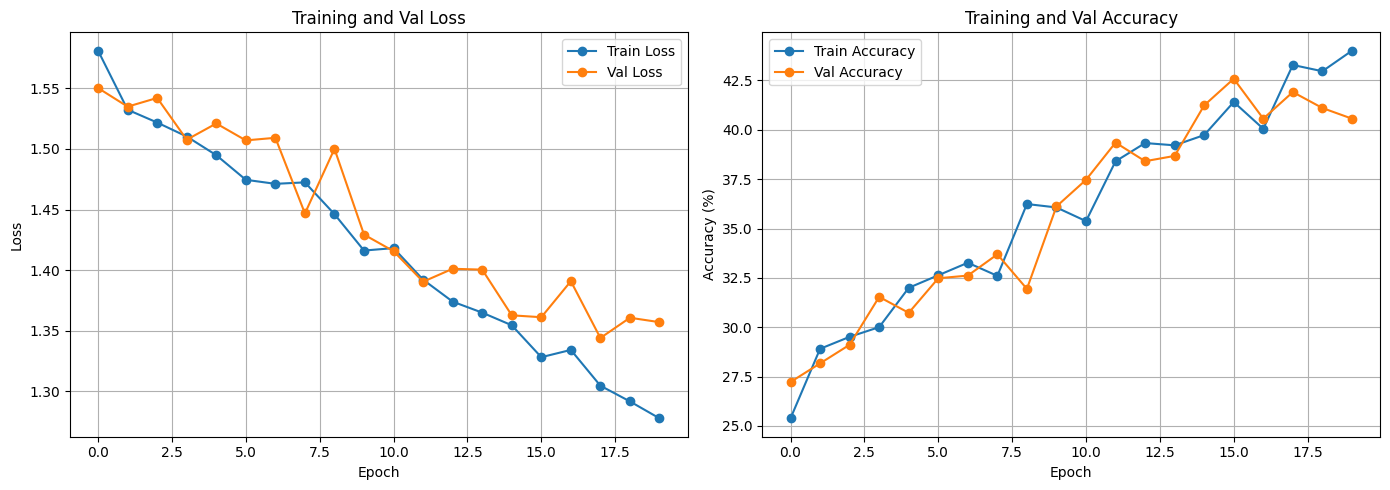

In [ ]:
plot_accuracy(train_losses, train_accs, val_losses, val_accs)

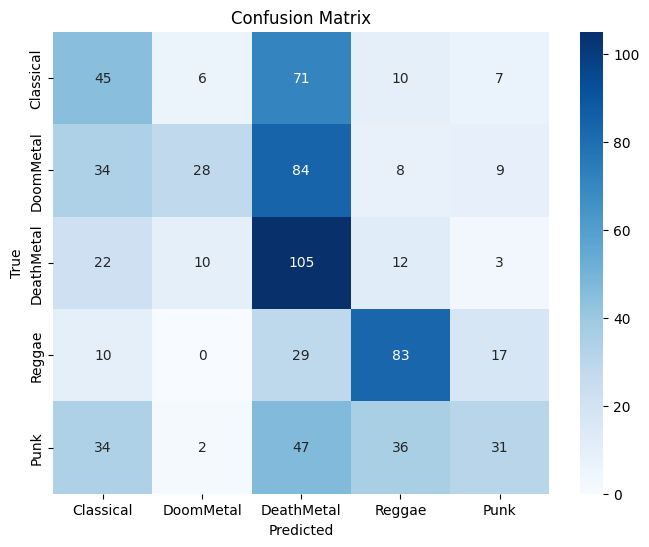

In [ ]:
cm = generate_confusion_matrix(y_true, y_pred, SELECTED_GENRES)

In [ ]:
from sklearn.metrics import f1_score, classification_report

# ── Per-class and macro F1 scores ─────────────────────────────────────────────
print("=" * 60)
print("BASELINE CNN — F1 Scores")
print("=" * 60)
print(classification_report(
    y_true,
    y_pred,
    target_names = SELECTED_GENRES
))


# ── Macro F1 for direct comparison ────────────────────────────────────────────
baseline_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Baseline Macro F1 : {baseline_f1:.4f}")


BASELINE CNN — F1 Scores
              precision    recall  f1-score   support

   Classical       0.31      0.32      0.32       139
   DoomMetal       0.61      0.17      0.27       163
  DeathMetal       0.31      0.69      0.43       152
      Reggae       0.56      0.60      0.58       139
        Punk       0.46      0.21      0.29       150

    accuracy                           0.39       743
   macro avg       0.45      0.40      0.38       743
weighted avg       0.45      0.39      0.37       743

Baseline Macro F1 : 0.3755
